# -------------------- Hyper Parameter Tunnning  ------------------

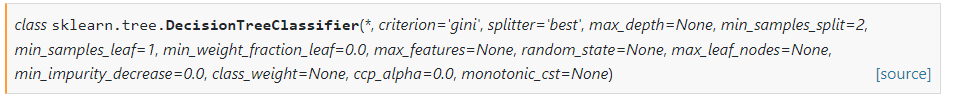

### criterion{“gini”, “entropy”, “log_loss”}, default=”gini”

```python
criterion{“gini”, “entropy”, “log_loss”}, default=”gini”
The function to measure the quality of a split. Supported criteria are “gini” for the Gini impurity and “log_loss” and “entropy” both for the Shannon information gain, see Mathematical formulation.

"Note"
1. Maximun cases we choose "gini"
```

### splitter{“best”, “random”}, default=”best”

```python
splitter{“best”, “random”}, default=”best”
The strategy used to choose the split at each node. Supported strategies are “best” to choose the best split and “random” to choose the best random split.
```
Split dataset for finding **Information Gain**(IG).<Br>
We can choose **random** instead of best it help us to reduce **Overfitting**

### max_depth : int, default=None

```python
max_depth : int, default=None
The maximum depth of the tree. If None, then nodes are expanded until all leaves are pure or until all leaves contain less than min_samples_split samples.

"Note"
1. If we choose "Max_depth" = None means we are not stopping tree depth, it may prone Tree to "Overfitting" condition
2. If we choose "Max_depth" = 1 then , it may prone Tree to "Underfitting" condition because decision making is very limited
```

### min_samples_split: int or float, default=2

```python
min_samples_split : int or float, default=2
The minimum number of samples required to split an internal node:

If int, then consider min_samples_split as the minimum number.

If float, then min_samples_split is a fraction and ceil(min_samples_split * n_samples) are the minimum number of samples for each split.

"Note"
1. Maximun the value of "min_samples_split" prone the model to "Underfiting"
2. Minmum the Value of "min_samples_split" prone the model to "Overfitting"
```

### min_samples_leaf : int or float, default=1

```python
min_samples_leaf: int or float, default=1
The minimum number of samples required to be at a leaf node. A split point at any depth will only be considered if it leaves at least min_samples_leaf training samples in each of the left and right branches. This may have the effect of smoothing the model, especially in regression.

If int, then consider min_samples_leaf as the minimum number.

If float, then min_samples_leaf is a fraction and ceil(min_samples_leaf * n_samples) are the minimum number of samples for each node.

"Note"
1. Maximun the value of "min_samples_leaf" prone the model to "Underfiting"
2. Minmum the Value of "min_samples_leaf" prone the model to "Overfitting"
```

### max_features : int, float or {“sqrt”, “log2”}, default=None

```python
max_featuresint, float or {“sqrt”, “log2”}, default=None
The number of features to consider when looking for the best split:

If int, then consider max_features features at each split.

If float, then max_features is a fraction and max(1, int(max_features * n_features_in_)) features are considered at each split.

If “sqrt”, then max_features=sqrt(n_features).

If “log2”, then max_features=log2(n_features).

If None, then max_features=n_features.

Note: the search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than max_features features.

"Note"
1. If we fix the value of "max_features" then split will done on the features of total no of features available in the dataset
2. This is done to Reduce "Overfitting"
```

### max_leaf_nodes : int, default=None

```python
max_leaf_nodesint, default=None
Grow a tree with max_leaf_nodes in best-first fashion. Best nodes are defined as relative reduction in impurity. If None then unlimited number of leaf nodes.
```

### min_impurity_decrease : float, default=0.0

```python
min_impurity_decrease : float, default=0.0
A node will be split if this split induces a decrease of the impurity greater than or equal to this value.

The weighted impurity decrease equation is the following:

N_t / N * (impurity - N_t_R / N_t * right_impurity
                    - N_t_L / N_t * left_impurity)
where N is the total number of samples, N_t is the number of samples at the current node, N_t_L is the number of samples in the left child, and N_t_R is the number of samples in the right child.

N, N_t, N_t_R and N_t_L all refer to the weighted sum, if sample_weight is passed.
```

# Note

```python
Hyper parameter is very important in Decision Tree because :-
1. Decision Tree use for Random forest
2. Decision Tree use in Bagging
3. Decision Tree use in Gradient Boosting
```

### Implementation 

In [29]:
import pandas as pd
#from pandas_datareader import data
import numpy as np
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import r2_score
#from sklearn.datasets import load_boston
import seaborn as sns

In [30]:
import seaborn as sns

# Load the 'iris' dataset
df = sns.load_dataset('iris')

In [31]:
df['species'].unique()

array(['setosa', 'versicolor', 'virginica'], dtype=object)

In [32]:
df['species'].replace({'setosa':0,'versicolor':1,'virginica':2},inplace = True)

In [33]:
df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [34]:
X = df.iloc[:,1:4]
y = df.iloc[:,-1]

In [35]:
y

0      0
1      0
2      0
3      0
4      0
      ..
145    2
146    2
147    2
148    2
149    2
Name: species, Length: 150, dtype: int64

In [50]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [51]:
from sklearn.tree import DecisionTreeClassifier
DTC = DecisionTreeClassifier()
DTC.fit(X_train,y_train)

DecisionTreeClassifier()

In [52]:
y_pred = DTC.predict(X_test)

In [53]:
y_pred

array([1, 0, 2, 1, 1, 0, 1, 2, 1, 1, 2, 0, 0, 0, 0, 1, 2, 1, 1, 2, 0, 2,
       0, 2, 2, 2, 2, 2, 0, 0])

In [54]:
from sklearn.metrics import accuracy_score
Accuracy  = accuracy_score(y_test,y_pred)
Accuracy

1.0

### Hyperparameter Tuning

In [91]:
param_grid = {
    'max_depth': [2, 4, 8, 10, None],
    'criterion': ['log_loss','gini','entropy'],  # Corrected criterion values
    'max_features': [0.25, 0.5, 1.0],
    'min_samples_split': [0.25, 0.5, 1.0]
}


In [92]:
from sklearn.model_selection import GridSearchCV

In [93]:

Tune_DTC = GridSearchCV(DecisionTreeClassifier(),param_grid=param_grid)

In [94]:
Tune_DTC.fit(X_Train,y_train)

GridSearchCV(estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['log_loss', 'gini', 'entropy'],
                         'max_depth': [2, 4, 8, 10, None],
                         'max_features': [0.25, 0.5, 1.0],
                         'min_samples_split': [0.25, 0.5, 1.0]})

In [95]:
Tune_DTC.best_score_

0.9333333333333333

In [96]:
Tune_DTC.best_params_

{'criterion': 'log_loss',
 'max_depth': 4,
 'max_features': 1.0,
 'min_samples_split': 0.25}

In [97]:
Tune_DTC.best_estimator_

DecisionTreeClassifier(criterion='log_loss', max_depth=4, max_features=1.0,
                       min_samples_split=0.25)

### Feature Importance

In [98]:
for importance, name in sorted(zip(DTC.feature_importances_, X_train.columns),reverse=True):
    print (name, importance)

petal_length 0.9061433868879218
petal_width 0.07718647349965893
sepal_width 0.016670139612419255
